# Strategy B vs A Comparison — Accuracy, Hallucination Rate, and Qualitative Analysis

Compare **Strategy A** (`opposite_label`) and **Strategy B** (`llm_negation`) on the FEVER
poisoning sweep using identical experimental conditions.

- **Strategy A**: samples distractor passages from opposite-label claims — cheap, deterministic,
  semantically distant from the original evidence.
- **Strategy B**: generates direct LLM negations of gold evidence passages — targeted,
  semantically close, more realistic as misinformation.

**Fixed variables**: prompt type = `standard`, k = 5, same 5 models, same poison rates.
**Variable**: poisoning strategy only.

**No new inference cost for Strategy A** (cache hits from notebook 05).
Strategy B negation calls are cached on first run.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DRY_RUN = False   # set False for the full experiment

SEED            = cfg["seed"]
K               = cfg["retrieval"]["k"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
EMB_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])
LLM_CACHE       = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["llm_subdir"])

MODELS          = cfg["models"]["available"]
PROMPT_TYPE     = "standard"
TEMPERATURE     = cfg["models"]["temperature"]
POISON_RATES    = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES      = 3 if DRY_RUN else cfg["evaluation"]["n_examples"]

STRATEGY_LABELS = {
    "opposite_label": "Strategy A (opposite_label)",
    "llm_negation":   "Strategy B (llm_negation)",
}
STRATEGY_COLORS = {
    "opposite_label": "#5C6BC0",
    "llm_negation":   "#FF7043",
}
STRATEGY_STYLES = {
    "opposite_label": "-",
    "llm_negation":   "--",
}

print(f"DRY_RUN={DRY_RUN}  n_examples={N_EXAMPLES}  prompt={PROMPT_TYPE}")
print(f"Grid: {len(POISON_RATES)} rates x 2 strategies x {len(MODELS)} models")

from nb_style import MODEL_LABELS


DRY_RUN=False  n_examples=50  prompt=standard
Grid: 5 rates x 2 strategies x 5 models


In [2]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.generation.llm_client import HuggingFaceClient
from src.evaluation.scorer import run as run_scorer

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])
examples = all_examples[:N_EXAMPLES]
print(f"Total loaded: {len(all_examples):,}  |  Using: {len(examples)}")

Total loaded: 15,935  |  Using: 50


In [3]:
def build_llm(model: str):
    return HuggingFaceClient(model=model, temperature=TEMPERATURE, cache_dir=LLM_CACHE)


def run_strategy_sweep(examples, poison_rates, prompt_type, k, embedder, llm,
                       distractor_pool, seed, strategy):
    # Sweep poison_rates for one (model, strategy, prompt_type) triple.
    # Returns list of row dicts; embedder and llm must already be open.
    rows = []
    model_name = llm._model
    for poison_rate in poison_rates:
        poisoned = (
            poison_dataset(
                examples, poison_rate=poison_rate, seed=seed,
                strategy=strategy, llm=llm,
            )
            if poison_rate > 0.0
            else examples
        )
        retriever = Retriever(embedder=embedder, k=k)
        metrics = run_scorer(
            examples=poisoned,
            retriever=retriever,
            llm=llm,
            prompt_type=prompt_type,
            distractor_pool_size=distractor_pool,
            seed=seed,
            self_consistency_runs=1,
        )
        rows.append({
            "model": model_name,
            "strategy": strategy,
            "poison_rate": poison_rate,
            "prompt_type": prompt_type,
            **metrics,
        })
        tag = "B" if strategy == "llm_negation" else "A"
        short = model_name.split("/")[-1][:14]
        print(
            f"  [Strategy {tag}]  {short:14s}  "
            f"rate={poison_rate:.2f}  acc={metrics['accuracy']:.3f}"
        )
    return rows

In [4]:
embedder = Embedder(model_name=EMBEDDING_MODEL, cache_dir=EMB_CACHE, device="cpu")
all_rows = []

print("Starting strategy comparison sweep ...")
for model_name in MODELS:
    print(f"\n--- Model: {model_name} ---")
    llm = build_llm(model_name)
    with llm:
        for strategy in ["opposite_label", "llm_negation"]:
            all_rows.extend(
                run_strategy_sweep(
                    examples=examples,
                    poison_rates=POISON_RATES,
                    prompt_type=PROMPT_TYPE,
                    k=K,
                    embedder=embedder,
                    llm=llm,
                    distractor_pool=DISTRACTOR_POOL,
                    seed=SEED,
                    strategy=strategy,
                )
            )

embedder.close()
results = pd.DataFrame(all_rows)
print(f"\nSweep done. {len(results)} conditions.")
results

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Starting strategy comparison sweep ...

--- Model: Qwen/Qwen2.5-1.5B-Instruct ---
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.00  acc=0.480
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.25  acc=0.440
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.50  acc=0.440
  [Strategy A]  Qwen2.5-1.5B-I  rate=0.75  acc=0.500
  [Strategy A]  Qwen2.5-1.5B-I  rate=1.00  acc=0.360
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.00  acc=0.480
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.25  acc=0.440
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.50  acc=0.460
  [Strategy B]  Qwen2.5-1.5B-I  rate=0.75  acc=0.480
  [Strategy B]  Qwen2.5-1.5B-I  rate=1.00  acc=0.400

--- Model: google/gemma-2-2b-it ---
  [Strategy A]  gemma-2-2b-it   rate=0.00  acc=0.700
  [Strategy A]  gemma-2-2b-it   rate=0.25  acc=0.640
  [Strategy A]  gemma-2-2b-it   rate=0.50  acc=0.600
  [Strategy A]  gemma-2-2b-it   rate=0.75  acc=0.560
  [Strategy A]  gemma-2-2b-it   rate=1.00  acc=0.540
  [Strategy B]  gemma-2-2b-it   rate=0.00  acc=0.700
  [Strategy B]  gemma-2-2b-it   r

,model,strategy,poison_rate,prompt_type,accuracy,macro_f1,hallucination_rate,precision_at_k
0,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.00,standard,0.48,0.464188,0.235294,0.208
1,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.25,standard,0.44,0.372975,0.176471,0.156
2,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.50,standard,0.44,0.379349,0.117647,0.132
3,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,0.75,standard,0.50,0.419514,0.058824,0.064
4,Qwen/Qwen2.5-1.5B-Instruct,opposite_label,1.00,standard,0.36,0.298246,0.235294,0.000
5,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.00,standard,0.48,0.464188,0.235294,0.208
6,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.25,standard,0.44,0.409524,0.235294,0.136
7,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.50,standard,0.46,0.413905,0.117647,0.100
8,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,0.75,standard,0.48,0.467901,0.294118,0.036
9,Qwen/Qwen2.5-1.5B-Instruct,llm_negation,1.00,standard,0.40,0.381032,0.352941,0.000


Saved -> figures/07_strategy_comparison_accuracy.png


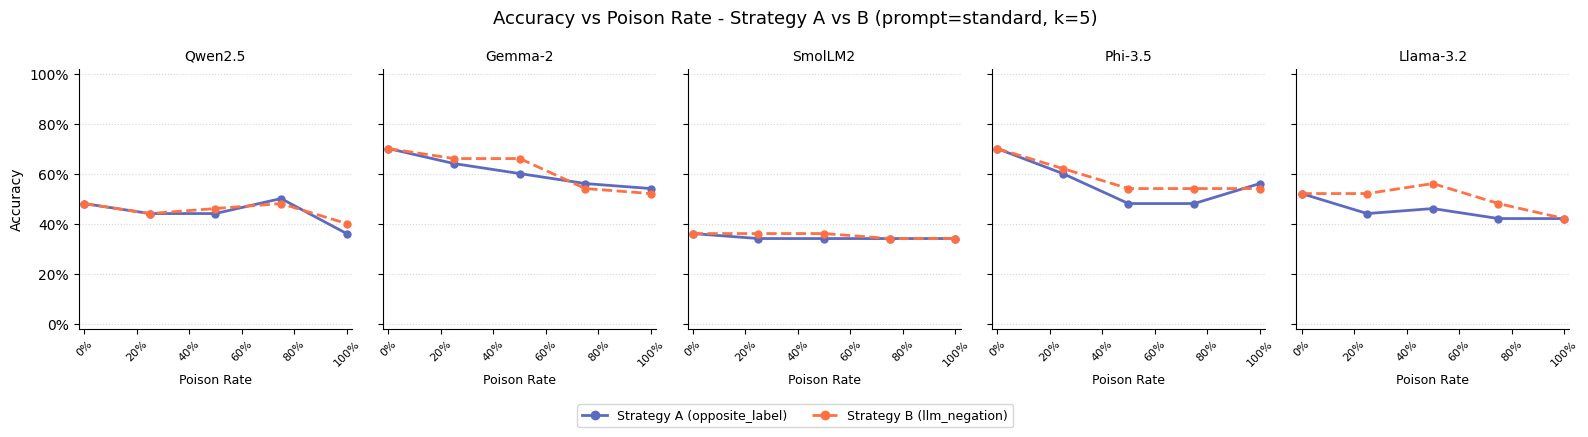

In [5]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for strategy in ["opposite_label", "llm_negation"]:
        sub = results[
            (results["model"] == model) & (results["strategy"] == strategy)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["accuracy"],
            marker="o", linewidth=2, markersize=5,
            color=STRATEGY_COLORS[strategy],
            linestyle=STRATEGY_STYLES[strategy],
            label=STRATEGY_LABELS[strategy],
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Accuracy")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=STRATEGY_COLORS[s], marker="o", linewidth=2,
               linestyle=STRATEGY_STYLES[s], label=STRATEGY_LABELS[s])
    for s in ["opposite_label", "llm_negation"]
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(
    f"Accuracy vs Poison Rate - Strategy A vs B (prompt={PROMPT_TYPE}, k={K})", fontsize=13
)
plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/07_strategy_comparison_accuracy.png", dpi=150, bbox_inches="tight")
    print("Saved -> figures/07_strategy_comparison_accuracy.png")
plt.show()

Saved -> figures/07_strategy_comparison_hallucination.png


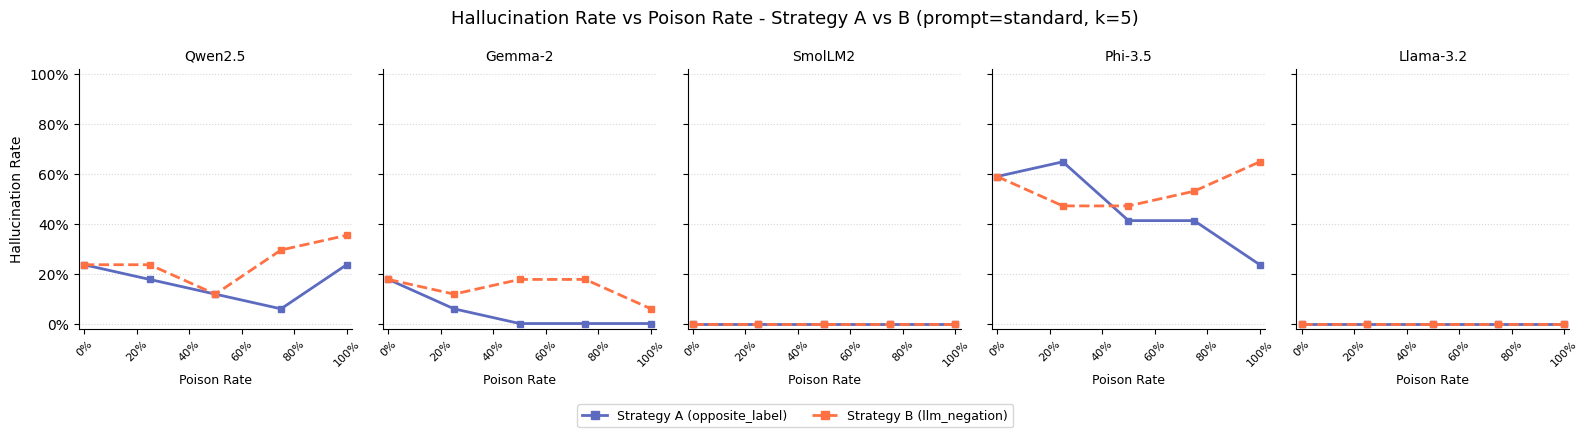

In [6]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 4), sharey=True)

for ax, model in zip(axes, MODELS):
    for strategy in ["opposite_label", "llm_negation"]:
        sub = results[
            (results["model"] == model) & (results["strategy"] == strategy)
        ].sort_values("poison_rate")
        ax.plot(
            sub["poison_rate"], sub["hallucination_rate"],
            marker="s", linewidth=2, markersize=5,
            color=STRATEGY_COLORS[strategy],
            linestyle=STRATEGY_STYLES[strategy],
            label=STRATEGY_LABELS[strategy],
        )
    ax.set_title(MODEL_LABELS[model], fontsize=10, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", labelrotation=45, labelsize=8)
    ax.set_xlabel("Poison Rate", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

axes[0].set_ylabel("Hallucination Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

handles = [
    plt.Line2D([0], [0], color=STRATEGY_COLORS[s], marker="s", linewidth=2,
               linestyle=STRATEGY_STYLES[s], label=STRATEGY_LABELS[s])
    for s in ["opposite_label", "llm_negation"]
]
fig.legend(handles=handles, fontsize=9, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.08))
fig.suptitle(
    f"Hallucination Rate vs Poison Rate - Strategy A vs B (prompt={PROMPT_TYPE}, k={K})", fontsize=13
)
plt.tight_layout()
if not DRY_RUN:
    plt.savefig("../figures/07_strategy_comparison_hallucination.png", dpi=150, bbox_inches="tight")
    print("Saved -> figures/07_strategy_comparison_hallucination.png")
plt.show()

In [7]:
pivot_acc = results.pivot_table(
    index="strategy",
    columns="model",
    values="accuracy",
    aggfunc="mean",
)
pivot_acc.columns = [MODEL_LABELS[m] for m in pivot_acc.columns]
pivot_acc.index = [STRATEGY_LABELS[s] for s in pivot_acc.index]

print("=== Mean Accuracy by Strategy x Model (averaged over all poison rates) ===")
print(pivot_acc.to_string(float_format="{:.3f}".format))
print()

delta = (
    pivot_acc.loc[STRATEGY_LABELS["llm_negation"]]
    - pivot_acc.loc[STRATEGY_LABELS["opposite_label"]]
)
print("=== Accuracy Delta (Strategy B - Strategy A) ===")
print(delta.to_string(float_format="{:+.3f}".format))
print("\nNegative = Strategy B is harder (lower accuracy) than Strategy A.")

=== Mean Accuracy by Strategy x Model (averaged over all poison rates) ===
                             SmolLM2  Qwen2.5  Gemma-2  Llama-3.2  Phi-3.5
Strategy B (llm_negation)      0.352    0.452    0.616      0.500    0.588
Strategy A (opposite_label)    0.344    0.444    0.608      0.452    0.564

=== Accuracy Delta (Strategy B - Strategy A) ===
SmolLM2     +0.008
Qwen2.5     +0.008
Gemma-2     +0.008
Llama-3.2   +0.048
Phi-3.5     +0.024

Negative = Strategy B is harder (lower accuracy) than Strategy A.


## Qualitative Examples — Strategy A vs B Poisoned Passages

Strategy A replaces a gold evidence passage with a **random passage from an opposite-label claim** —
typically semantically unrelated to the original.

Strategy B replaces it with a **direct LLM negation** of the original — factually inverted while
retaining the same subject and surface form. These are harder to dismiss than unrelated distractors.

The examples below run both strategies at `poison_rate=1.0` so every evidence passage is replaced,
making the contrast maximal. No new inference cost after the sweep above.

In [8]:
QUAL_EXAMPLES = all_examples[:min(5, N_EXAMPLES)]
QUAL_MODEL    = MODELS[0]  # Qwen2.5 - negations cached from sweep above

llm_qual = build_llm(QUAL_MODEL)
with llm_qual:
    poisoned_a = poison_dataset(
        QUAL_EXAMPLES, poison_rate=1.0, seed=SEED, strategy="opposite_label"
    )
    poisoned_b = poison_dataset(
        QUAL_EXAMPLES, poison_rate=1.0, seed=SEED,
        strategy="llm_negation", llm=llm_qual,
    )

print(f"Built poisoned examples for {len(QUAL_EXAMPLES)} claims.")

Built poisoned examples for 5 claims.


In [9]:
SEP = "=" * 72

for i, (orig, pa, pb) in enumerate(zip(QUAL_EXAMPLES, poisoned_a, poisoned_b), 1):
    print(f"\n{SEP}")
    print(f"  Example {i}")
    print(SEP)
    print(f"  CLAIM : {orig['claim']}")
    print(f"  LABEL : {orig['label']}")
    for j, (ev_orig, ev_a, ev_b) in enumerate(
        zip(orig["evidence"], pa["evidence"], pb["evidence"]), 1
    ):
        print(f"\n  Passage {j}:")
        print(f"    ORIGINAL   : {ev_orig[:130]}")
        print(f"    Strategy A : {ev_a[:130]}")
        print(f"    Strategy B : {ev_b[:130]}")


  Example 1
  CLAIM : Jackie (2016 film) was directed by Peter Jackson.
  LABEL : REFUTES

  Passage 1:
    ORIGINAL   : Jackie is a 2016 biographical drama film directed by Pablo Larraín and written by Noah Oppenheim .
    Strategy A : At the 2010 census , the city population was 145,170 , and its metropolitan area had a population of 662,577 .
    Strategy B : Pablo Larraín directed the 2016 biographical drama film "Jackie" with Noah Oppenheim writing it.

  Example 2
  CLAIM : The CONCACAF Champions League is organized for the top baseball clubs.
  LABEL : REFUTES

  Passage 1:
    ORIGINAL   : The CONCACAF Champions League is an annual continental football club competition organized by CONCACAF for the top football clubs 
    Strategy A : At the 2010 census , the city population was 145,170 , and its metropolitan area had a population of 662,577 .
    Strategy B : The CARIBBEAN CHAMPIONS LEAGUE is a biennial regional soccer tournament managed by FIFA for elite teams across South A